# Temporal evolution of measured eddy tilt

This notebook tests the literature prediction that vertical tilt accumulates as the upper and lower eddy centres propagate differently. It uses the existing `TiltDis` and `TiltDir` measurements and never re-estimates tilt.

The analysis separates three related questions:

1. Does tilt magnitude grow within individual eddies as they age?
2. Is growth different for eddies persistently exposed to planetary- or topographic-PV dominance?
3. Do observed day-to-day tilt-vector changes follow the measured surface-minus-deep centre displacement?


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest, spearmanr, wilcoxon
import statsmodels.formula.api as smf

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

sns.set_theme(style="ticks", context="notebook")
palette = {"AE": "#d95f02", "CE": "#1f78b4"}
exposure_order = ["planetary-dominated", "transitional/mixed", "topographic-dominated"]
exposure_palette = dict(zip(exposure_order, ["#4575b4", "#999999", "#d73027"]))

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


## Temporal coordinates and environmental exposure

Daily PV dominance uses the same two-to-one threshold as notebook 03. An eddy is labelled *planetary-dominated* or *topographic-dominated* only when at least two-thirds of its observed life occupies that regime; all others are transitional/mixed. This avoids assigning an entire trajectory from one instantaneous location.


In [2]:
data = tilt.add_pv_gradient_terms(df, grid)
data = tilt.add_region_labels(data, grid)
data = mech.add_topographic_regimes(data, shelf_depth=2000.0, dominance_ratio=2.0)
data = mech.add_eddy_pv_exposure_class(data, stable_fraction=2 / 3)
data = mech.add_temporal_tilt_changes(data, max_gap_days=2)
data["slope_mag"] = np.hypot(data.dhdx, data.dhdy)
data["life_stage"] = pd.cut(data.norm_age, [0, .25, .75, 1], include_lowest=True,
                                 labels=["young", "mature", "decaying"])
data["age_bin_days"] = pd.cut(data.age_days, np.arange(0, 131, 10), right=False)
data["norm_age_bin"] = pd.cut(data.norm_age, np.linspace(0, 1, 11), include_lowest=True)
display(data[["TiltDis", "age_days", "lifetime_days", "dtilt_km_day",
              "topo_plan_ratio_raw", "slope_mag"]].describe().T)
display(pd.crosstab(data.Cyc, data.PVExposure, values=data.Eddy, aggfunc="nunique", margins=True))


,count,mean,std,min,25%,50%,75%,max
TiltDis,105621.0,23.866543,21.018172,0.010263,9.531714,17.663528,31.568400,266.951190
age_days,127426.0,30.818663,36.651794,0.000000,10.000000,21.000000,37.000000,461.000000
lifetime_days,127426.0,61.637327,55.221787,21.000000,30.000000,43.000000,73.000000,461.000000
dtilt_km_day,102468.0,0.009377,8.252934,-168.874243,-1.651757,0.019855,1.766729,198.409200
topo_plan_ratio_raw,127424.0,26.449322,78.652579,0.005760,1.725192,4.375227,18.109032,1491.267965
slope_mag,127424.0,0.014022,0.022277,0.000011,0.002035,0.004430,0.015407,0.163771


PVExposure,planetary-dominated,topographic-dominated,transitional/mixed,All
Cyc,,,,
AE,6.0,854.0,586.0,1446
CE,NaN,1269.0,267.0,1536
All,6.0,2123.0,853.0,2982


eddies  median_lifetime  median_valid_days  \
Cyc PVExposure                                                          
AE  planetary-dominated         6             26.0               21.0   
    topographic-dominated     854             30.0               24.0   
    transitional/mixed        586             38.0               31.0   
CE  topographic-dominated    1269             32.0               26.0   
    transitional/mixed        267             33.0               27.0   

                           median_coverage  
Cyc PVExposure                              
AE  planetary-dominated           0.777473  
    topographic-dominated         0.785714  
    transitional/mixed            0.833333  
CE  topographic-dominated         0.806452  
    transitional/mixed            0.818182

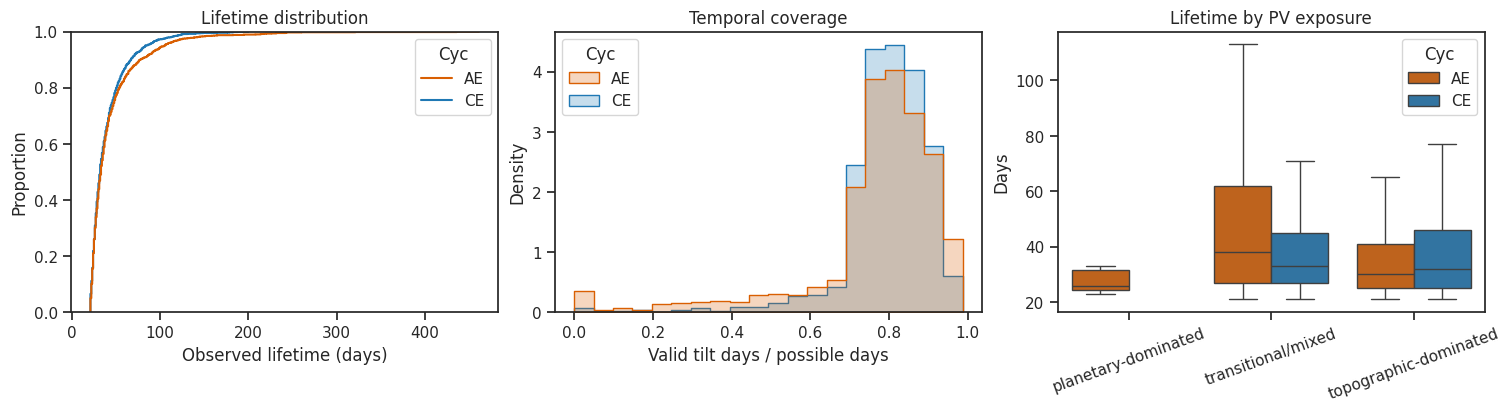

In [3]:
# Sampling and lifetime QC: short records can otherwise create artificial age patterns.
eddy_qc = (data.groupby(["Cyc", "Eddy", "PVExposure"], observed=True)
           .agg(first_day=("Day", "min"), last_day=("Day", "max"),
                lifetime_days=("lifetime_days", "max"), rows=("Day", "size"),
                valid_tilts=("TiltDis", "count"), median_gap=("dt_days", "median"),
                max_gap=("dt_days", "max"))
           .reset_index())
eddy_qc["coverage"] = eddy_qc.valid_tilts / (eddy_qc.lifetime_days + 1)
display(eddy_qc.groupby(["Cyc", "PVExposure"], observed=True)
        .agg(eddies=("Eddy", "size"), median_lifetime=("lifetime_days", "median"),
             median_valid_days=("valid_tilts", "median"), median_coverage=("coverage", "median")))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
sns.ecdfplot(data=eddy_qc, x="lifetime_days", hue="Cyc", palette=palette, ax=axes[0])
sns.histplot(data=eddy_qc, x="coverage", hue="Cyc", bins=20, element="step",
             stat="density", common_norm=False, palette=palette, ax=axes[1])
sns.boxplot(data=eddy_qc, x="PVExposure", y="lifetime_days", hue="Cyc",
            order=exposure_order, palette=palette, showfliers=False, ax=axes[2])
axes[0].set(title="Lifetime distribution", xlabel="Observed lifetime (days)")
axes[1].set(title="Temporal coverage", xlabel="Valid tilt days / possible days")
axes[2].set(title="Lifetime by PV exposure", xlabel="", ylabel="Days")
axes[2].tick_params(axis="x", rotation=20)
plt.show()


## Ensemble evolution

Absolute age answers whether tilt accumulates over days. Normalised age compares eddies with different lifetimes, but can be affected by retrospective lifetime selection. The plots therefore show both, using one median per eddy per bin before calculating the ensemble median and interquartile range.


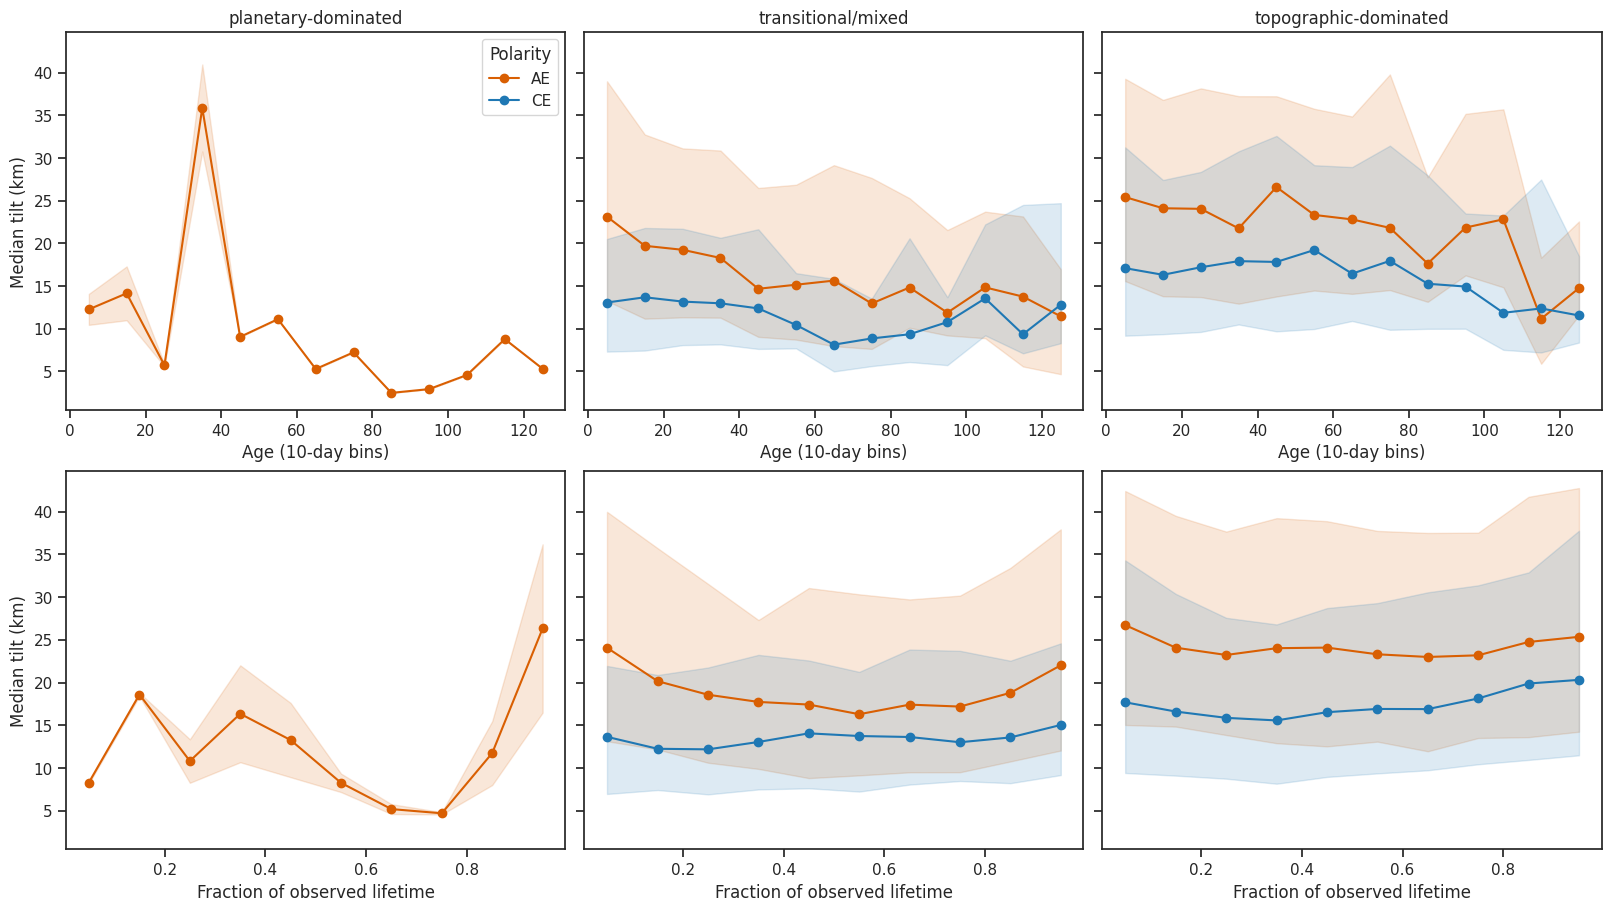

In [4]:
def eddy_equal_curve(frame, bin_column):
    per_eddy = (frame.dropna(subset=[bin_column, "TiltDis"])
                .groupby(["Cyc", "PVExposure", "Eddy", bin_column], observed=True)
                .TiltDis.median().reset_index())
    return (per_eddy.groupby(["Cyc", "PVExposure", bin_column], observed=True)
            .TiltDis.agg(median="median", low=lambda x: x.quantile(.25),
                         high=lambda x: x.quantile(.75), eddies="size").reset_index())

absolute_curve = eddy_equal_curve(data[data.lifetime_days >= 30], "age_bin_days")
normalised_curve = eddy_equal_curve(data[data.lifetime_days >= 30], "norm_age_bin")
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True, constrained_layout=True)
for column, exposure in enumerate(exposure_order):
    for row, (curve, bin_col, xlabel) in enumerate([
        (absolute_curve, "age_bin_days", "Age (10-day bins)"),
        (normalised_curve, "norm_age_bin", "Fraction of observed lifetime")]):
        ax = axes[row, column]
        for cyc in ["AE", "CE"]:
            part = curve[(curve.PVExposure == exposure) & (curve.Cyc == cyc)].copy()
            part["x"] = part[bin_col].apply(lambda interval: interval.mid).astype(float)
            ax.plot(part.x, part["median"], "o-", color=palette[cyc], label=cyc)
            ax.fill_between(part.x.to_numpy(), part.low.to_numpy(), part.high.to_numpy(),
                            color=palette[cyc], alpha=.15)
        ax.set(title=exposure if row == 0 else "", xlabel=xlabel,
               ylabel="Median tilt (km)" if column == 0 else "")
        if row == 0 and column == 0:
            ax.legend(title="Polarity")
plt.show()


/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


,Cyc,PVExposure,eddies,median_slope_km_day,ci_low,ci_high,fraction_positive,one_sided_wilcoxon_p
0,AE,planetary-dominated,3,-0.268002,-0.295165,-0.012127,0.000000,NaN
1,AE,topographic-dominated,547,0.024860,-0.034955,0.079861,0.522852,0.222304
2,AE,transitional/mixed,453,-0.025402,-0.058204,0.015996,0.474614,0.767014
3,CE,topographic-dominated,887,0.044093,0.010358,0.078205,0.540023,0.001885
4,CE,transitional/mixed,207,0.010552,-0.028329,0.069664,0.526570,0.347631


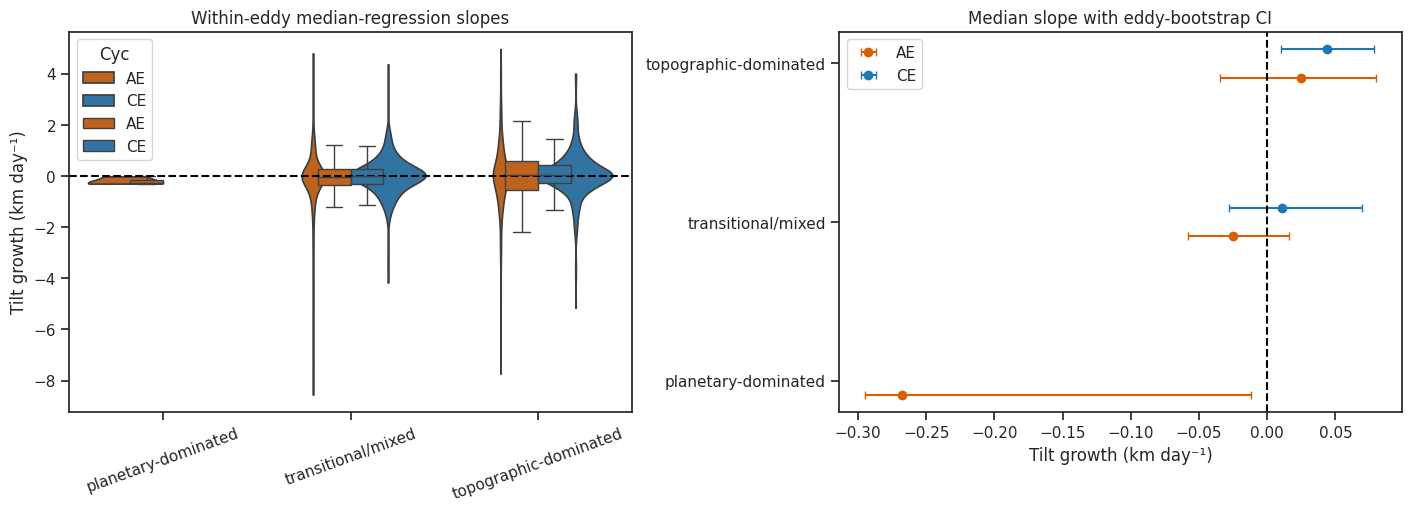

In [5]:
# Each eddy supplies one robust age slope; require at least 10 valid days and 20-day span.
slope_rows = []
for (cyc, eddy, exposure), part in data.groupby(["Cyc", "Eddy", "PVExposure"], observed=True):
    use = part[["age_days", "TiltDis"]].dropna().drop_duplicates("age_days")
    if len(use) < 10 or use.age_days.max() - use.age_days.min() < 20:
        continue
    fit = smf.quantreg("TiltDis ~ age_days", data=use).fit(q=.5)
    slope_rows.append({"Cyc": cyc, "Eddy": eddy, "PVExposure": exposure,
                       "days": len(use), "span": use.age_days.max() - use.age_days.min(),
                       "slope_km_day": fit.params["age_days"]})
eddy_slopes = pd.DataFrame(slope_rows)
test_rows = []
for (cyc, exposure), part in eddy_slopes.groupby(["Cyc", "PVExposure"], observed=True):
    values = part.slope_km_day.dropna().to_numpy()
    test = wilcoxon(values, alternative="greater") if len(values) >= 10 else None
    rng = np.random.default_rng(42)
    boot = np.median(rng.choice(values, (5000, len(values)), replace=True), axis=1) if len(values) else [np.nan]
    test_rows.append({"Cyc": cyc, "PVExposure": exposure, "eddies": len(values),
                      "median_slope_km_day": np.median(values),
                      "ci_low": np.quantile(boot, .025), "ci_high": np.quantile(boot, .975),
                      "fraction_positive": np.mean(values > 0),
                      "one_sided_wilcoxon_p": test.pvalue if test else np.nan})
slope_tests = pd.DataFrame(test_rows)
display(slope_tests)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.violinplot(data=eddy_slopes, x="PVExposure", y="slope_km_day", hue="Cyc",
               order=exposure_order, palette=palette, inner=None, cut=0, ax=axes[0])
sns.boxplot(data=eddy_slopes, x="PVExposure", y="slope_km_day", hue="Cyc",
            order=exposure_order, palette=palette, width=.35, showfliers=False, ax=axes[0])
axes[0].axhline(0, color="black", ls="--")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set(title="Within-eddy median-regression slopes", xlabel="", ylabel="Tilt growth (km day⁻¹)")
for i, cyc in enumerate(["AE", "CE"]):
    part = slope_tests[slope_tests.Cyc == cyc].set_index("PVExposure").reindex(exposure_order)
    y = np.arange(3) + (i - .5) * .18
    axes[1].errorbar(part.median_slope_km_day, y,
                     xerr=[part.median_slope_km_day - part.ci_low, part.ci_high - part.median_slope_km_day],
                     fmt="o", capsize=3, color=palette[cyc], label=cyc)
axes[1].axvline(0, color="black", ls="--")
axes[1].set_yticks(np.arange(3), exposure_order)
axes[1].set(title="Median slope with eddy-bootstrap CI", xlabel="Tilt growth (km day⁻¹)")
axes[1].legend()
plt.show()


In [6]:
# Clustered repeated-observation models: linear growth, curvature, and PV-exposure interaction.
gee_rows, gee_fits = [], {}
for cyc, part in data[data.lifetime_days >= 20].groupby("Cyc"):
    use = part[["Eddy", "TiltDis", "age_days", "PVExposure", "Rc", "h", "beta"]].dropna().copy()
    use["log_tilt"] = np.log1p(use.TiltDis)
    use["age_10d"] = use.age_days / 10
    use["age_10d_sq"] = use.age_10d ** 2
    for column in ["Rc", "h", "beta"]:
        use[f"z_{column}"] = (use[column] - use[column].mean()) / use[column].std()
    formulas = {
        "linear": "log_tilt ~ age_10d + z_Rc + z_h + z_beta",
        "curved": "log_tilt ~ age_10d + age_10d_sq + z_Rc + z_h + z_beta",
        "exposure_interaction": "log_tilt ~ age_10d * C(PVExposure) + age_10d_sq + z_Rc + z_h + z_beta",
    }
    for name, formula in formulas.items():
        fit = smf.gee(formula, groups="Eddy", data=use).fit()
        gee_fits[(cyc, name)] = fit
        qic = fit.qic(scale=1.0)[0]
        gee_rows.append({"Cyc": cyc, "model": name, "rows": len(use),
                         "eddies": use.Eddy.nunique(), "QIC": qic})
gee_comparison = pd.DataFrame(gee_rows)
gee_comparison["delta_QIC"] = gee_comparison.QIC - gee_comparison.groupby("Cyc").QIC.transform("min")
display(gee_comparison)
effect_rows = []
for (cyc, name), fit in gee_fits.items():
    for term in fit.params.index:
        if term == "age_10d" or ("age_10d" in term and "PVExposure" in term):
            ci = fit.conf_int().loc[term]
            effect_rows.append({"Cyc": cyc, "model": name, "term": term,
                                "estimate": fit.params[term], "low": ci.iloc[0],
                                "high": ci.iloc[1], "p": fit.pvalues[term]})
gee_effects = pd.DataFrame(effect_rows)
display(gee_effects)


,Cyc,model,rows,eddies,QIC,delta_QIC
0,AE,linear,53607,1422,30577.342374,330.952584
1,AE,curved,53607,1422,30506.172954,259.783164
2,AE,exposure_interaction,53607,1422,30246.389790,0.000000
3,CE,linear,52014,1531,28897.573873,41.972300
4,CE,curved,52014,1531,28900.606142,45.004569
5,CE,exposure_interaction,52014,1531,28855.601573,0.000000


,Cyc,model,term,estimate,low,high,p
0,AE,linear,age_10d,-0.032370,-0.038138,-0.026603,3.820998e-28
1,AE,curved,age_10d,-0.049088,-0.062784,-0.035391,2.149675e-12
2,AE,exposure_interaction,age_10d,-0.064115,-0.087700,-0.040530,9.926487e-08
3,AE,exposure_interaction,age_10d:C(PVExposure)[T.topographic-dominated],0.035288,0.010911,0.059665,4.550719e-03
4,AE,exposure_interaction,age_10d:C(PVExposure)[T.transitional/mixed],0.006781,-0.015712,0.029274,5.545891e-01
5,CE,linear,age_10d,-0.012215,-0.022585,-0.001845,2.096587e-02
6,CE,curved,age_10d,-0.000572,-0.022328,0.021184,9.588870e-01
7,CE,exposure_interaction,age_10d,0.004370,-0.015794,0.024535,6.709909e-01
8,CE,exposure_interaction,age_10d:C(PVExposure)[T.transitional/mixed],-0.034774,-0.057668,-0.011879,2.911644e-03


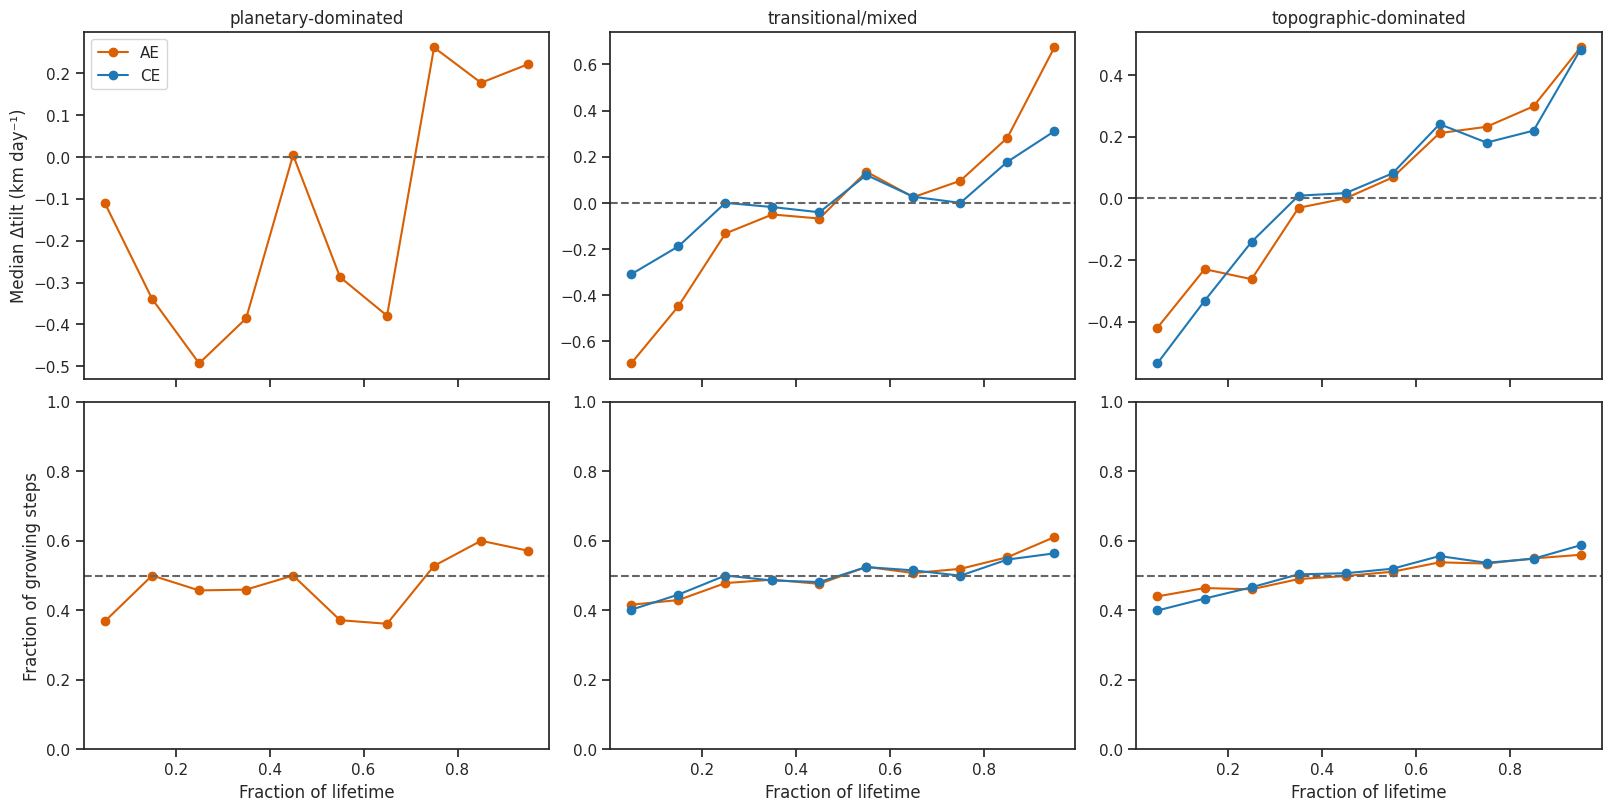

,Cyc,PVExposure,eddies,eddies_mostly_growing,binomial_p
0,AE,planetary-dominated,6,1,0.984375
1,AE,topographic-dominated,839,414,0.660655
2,AE,transitional/mixed,576,274,0.886556
3,CE,topographic-dominated,1264,631,0.533621
4,CE,transitional/mixed,267,125,0.864694


In [7]:
# Growth is not necessarily monotonic: inspect positive increments and reversals through life.
increments = data.dropna(subset=["dtilt_km_day", "norm_age_bin"]).copy()
increment_summary = (increments.groupby(["Cyc", "PVExposure", "norm_age_bin"], observed=True)
                     .agg(median_change=("dtilt_km_day", "median"),
                          positive_fraction=("dtilt_km_day", lambda x: np.mean(x > 0)),
                          rows=("dtilt_km_day", "size"), eddies=("Eddy", "nunique"))
                     .reset_index())
increment_summary["x"] = increment_summary.norm_age_bin.apply(lambda x: x.mid).astype(float)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, constrained_layout=True)
for column, exposure in enumerate(exposure_order):
    for cyc in ["AE", "CE"]:
        part = increment_summary[(increment_summary.PVExposure == exposure) & (increment_summary.Cyc == cyc)]
        axes[0, column].plot(part.x, part.median_change, "o-", color=palette[cyc], label=cyc)
        axes[1, column].plot(part.x, part.positive_fraction, "o-", color=palette[cyc], label=cyc)
    axes[0, column].axhline(0, color="0.4", ls="--")
    axes[1, column].axhline(.5, color="0.4", ls="--")
    axes[0, column].set(title=exposure, ylabel="Median Δtilt (km day⁻¹)" if column == 0 else "")
    axes[1, column].set(xlabel="Fraction of lifetime", ylabel="Fraction of growing steps" if column == 0 else "", ylim=(0, 1))
axes[0, 0].legend()
plt.show()
sign_rows = []
for (cyc, exposure), part in increments.groupby(["Cyc", "PVExposure"], observed=True):
    # One sign fraction per eddy prevents long tracks dominating the test.
    fractions = part.groupby("Eddy").dtilt_km_day.apply(lambda x: np.mean(x > 0))
    positive_eddies = int((fractions > .5).sum())
    test = binomtest(positive_eddies, len(fractions), .5, alternative="greater")
    sign_rows.append({"Cyc": cyc, "PVExposure": exposure, "eddies": len(fractions),
                      "eddies_mostly_growing": positive_eddies, "binomial_p": test.pvalue})
display(pd.DataFrame(sign_rows))


## Direct kinematic test: surface-minus-deep displacement

If vertical differential propagation causes tilt, the daily change in the measured tilt vector should covary component-by-component with the surface-centre displacement minus the deep-centre displacement. Agreement in magnitude alone is insufficient; east and north components and vector alignment are tested separately.


In [8]:
dic_vert = tilt.load_vert(paths, dic_form=True)
kinematic = tilt.add_top_bottom_speeds(data.sort_values(["Eddy", "Day"]), dic_vert, zmax=1000.0)
alpha = grid.angle#[kinematic.ic.to_numpy(int), kinematic.jc.to_numpy(int)]
for level in ["top", "btm"]:
    dx = kinematic[f"dx_{level}"].to_numpy(float)
    dy = kinematic[f"dy_{level}"].to_numpy(float)
    kinematic[f"d{level}_east_km"] = dx * np.cos(alpha) - dy * np.sin(alpha)
    kinematic[f"d{level}_north_km"] = dx * np.sin(alpha) + dy * np.cos(alpha)
for component in ["east", "north"]:
    kinematic[f"depth_diff_{component}_km_day"] = (
        kinematic[f"dtop_{component}_km"] - kinematic[f"dbtm_{component}_km"]
    ) / kinematic.dt_days
kinematic["depth_diff_mag_km_day"] = np.hypot(kinematic.depth_diff_east_km_day,
                                                    kinematic.depth_diff_north_km_day)
kinematic["depth_diff_dir"] = mech.bearing_from_east_north(
    kinematic.depth_diff_east_km_day, kinematic.depth_diff_north_km_day)
kinematic["observed_change_mag_km_day"] = np.hypot(kinematic.dtilt_east_km_day,
                                                         kinematic.dtilt_north_km_day)
kinematic["observed_change_dir"] = mech.bearing_from_east_north(
    kinematic.dtilt_east_km_day, kinematic.dtilt_north_km_day)
kinematic["change_prediction_offset"] = mech.signed_angle_difference(
    kinematic.observed_change_dir, kinematic.depth_diff_dir)
valid = kinematic[["depth_diff_mag_km_day", "observed_change_mag_km_day"]].notna().all(axis=1)
print(f"Kinematic comparison: {valid.sum():,} eddy-days from {kinematic.loc[valid, 'Eddy'].nunique():,} eddies")


Kinematic comparison: 95,015 eddy-days from 2,947 eddies


,Cyc,PVExposure,component,rows,eddies,slope,ci_low,ci_high,p
0,AE,planetary-dominated,east,320,6,0.076274,0.052715,0.099832,2.215516e-10
1,AE,planetary-dominated,north,320,6,0.015163,-0.060854,0.091181,6.958281e-01
2,AE,transitional/mixed,east,25654,575,0.035252,0.021021,0.049483,1.203275e-06
3,CE,transitional/mixed,east,8207,266,0.025151,0.005832,0.044469,1.072130e-02
4,AE,transitional/mixed,north,25654,575,0.037654,0.026077,0.049230,1.829432e-10
5,CE,transitional/mixed,north,8207,266,0.017773,-0.001348,0.036894,6.848328e-02
6,AE,topographic-dominated,east,22594,837,0.021748,0.010024,0.033472,2.771355e-04
7,CE,topographic-dominated,east,38240,1263,0.022688,0.013778,0.031597,6.008294e-07
8,AE,topographic-dominated,north,22594,837,0.014862,-0.000190,0.029914,5.296309e-02
9,CE,topographic-dominated,north,38240,1263,0.021811,0.013072,0.030551,1.001493e-06


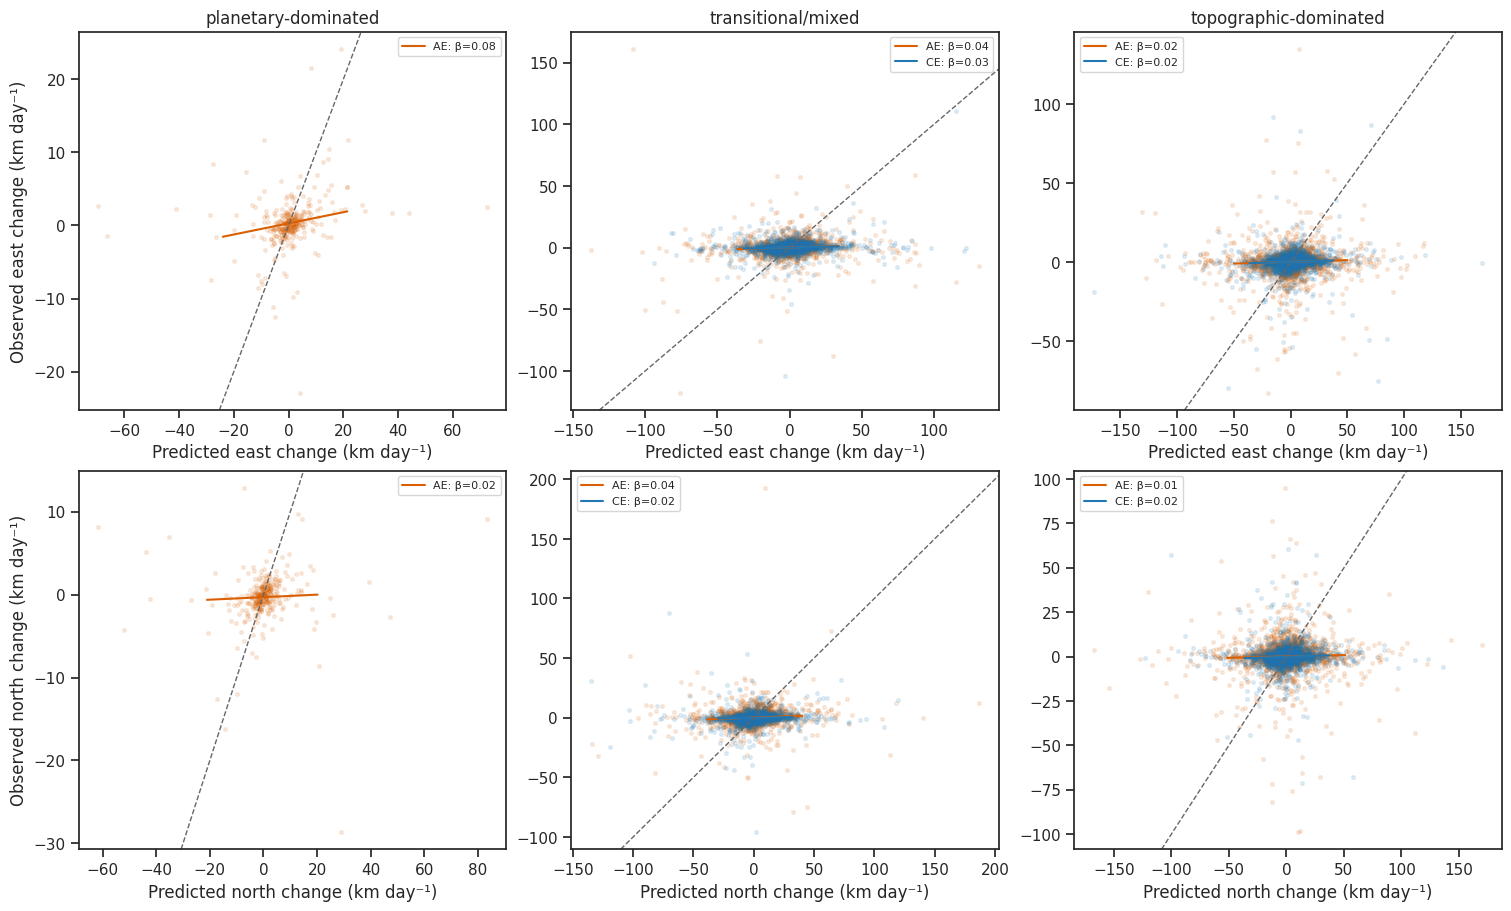

In [9]:
kinematic_rows = []
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
for column, exposure in enumerate(exposure_order):
    part_exposure = kinematic[kinematic.PVExposure == exposure]
    for row, component in enumerate(["east", "north"]):
        x = f"depth_diff_{component}_km_day"
        y = f"dtilt_{component}_km_day"
        for cyc in ["AE", "CE"]:
            use = part_exposure[part_exposure.Cyc == cyc].dropna(subset=[x, y, "Eddy"]).copy()
            if len(use) < 30 or use.Eddy.nunique() < 5:
                continue
            fit = smf.gee(f"{y} ~ {x}", groups="Eddy", data=use).fit()
            ci = fit.conf_int().loc[x]
            kinematic_rows.append({"Cyc": cyc, "PVExposure": exposure, "component": component,
                                   "rows": len(use), "eddies": use.Eddy.nunique(),
                                   "slope": fit.params[x], "ci_low": ci.iloc[0],
                                   "ci_high": ci.iloc[1], "p": fit.pvalues[x]})
            sample = use.sample(min(3000, len(use)), random_state=42)
            axes[row, column].scatter(sample[x], sample[y], s=7, alpha=.12, color=palette[cyc])
            xx = np.linspace(use[x].quantile(.02), use[x].quantile(.98), 50)
            axes[row, column].plot(xx, fit.params.Intercept + fit.params[x] * xx,
                                   color=palette[cyc], label=f"{cyc}: β={fit.params[x]:.2f}")
        axes[row, column].axline((0, 0), slope=1, color="0.4", ls="--", lw=1)
        axes[row, column].set(title=exposure if row == 0 else "",
                              xlabel=f"Predicted {component} change (km day⁻¹)",
                              ylabel=f"Observed {component} change (km day⁻¹)" if column == 0 else "")
        axes[row, column].legend(fontsize=8)
kinematic_tests = pd.DataFrame(kinematic_rows)
display(kinematic_tests)
plt.show()


,Cyc,PVExposure,life_stage,metric,eddies,mean_offset_deg,resultant_length,median_abs_offset_deg
0,AE,planetary-dominated,young,change_prediction_offset,6,10.394446,0.786196,226.070335
1,AE,planetary-dominated,mature,change_prediction_offset,6,20.059760,0.918891,33.586791
2,AE,planetary-dominated,decaying,change_prediction_offset,6,-8.593474,0.696930,23.807825
3,AE,topographic-dominated,young,change_prediction_offset,765,9.708020,0.204747,171.501792
4,AE,topographic-dominated,mature,change_prediction_offset,833,0.865566,0.406643,176.964150
5,AE,topographic-dominated,decaying,change_prediction_offset,761,-11.960668,0.216118,191.799342
6,AE,transitional/mixed,young,change_prediction_offset,541,0.998949,0.399614,168.985288
7,AE,transitional/mixed,mature,change_prediction_offset,572,-2.268096,0.500274,181.369224
8,AE,transitional/mixed,decaying,change_prediction_offset,550,-1.028391,0.379923,186.168753
9,CE,topographic-dominated,young,change_prediction_offset,1184,-10.509525,0.338646,210.480762


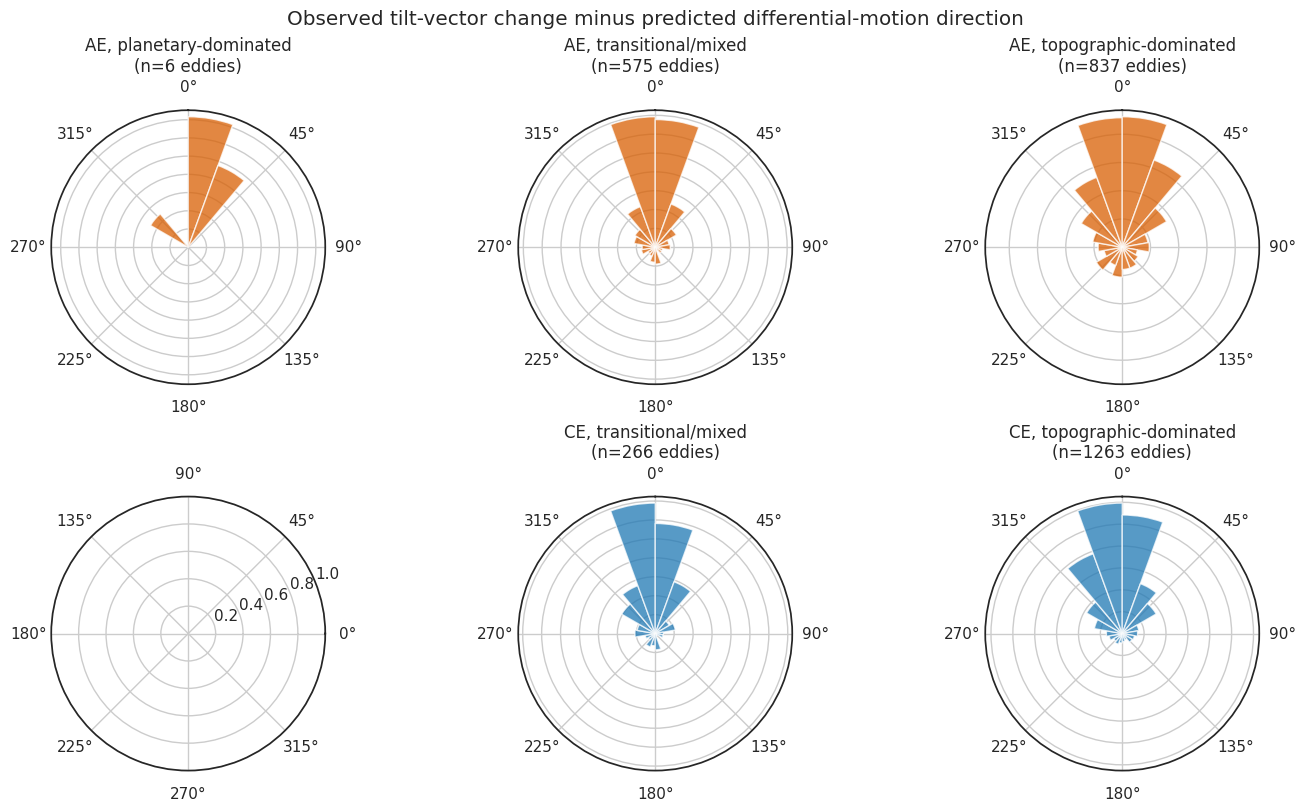

In [11]:
# Directional agreement and its evolution through the eddy life cycle.
direction_summary = mech.circular_offset_summary(
    kinematic, ["change_prediction_offset"], group=("Cyc", "PVExposure", "life_stage"),
    eddy_equal=True)
display(direction_summary)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), subplot_kw={"projection": "polar"},
                         constrained_layout=True)
bins = np.deg2rad(np.arange(-180, 181, 20))
for row, cyc in enumerate(["AE", "CE"]):
    for column, exposure in enumerate(exposure_order):
        values = (kinematic[(kinematic.Cyc == cyc) & (kinematic.PVExposure == exposure)]
                  .groupby("Eddy").change_prediction_offset
                  .apply(lambda x: tilt.circular_mean_deg_true_north(x.dropna())))
        values = ((values + 180) % 360 - 180).dropna()
        if len(values) == 0:
            continue
        axes[row, column].hist(np.deg2rad(values), bins=bins, density=True,
                               color=palette[cyc], alpha=.75)
        axes[row, column].set_theta_zero_location("N")
        axes[row, column].set_theta_direction(-1)
        axes[row, column].set_yticklabels([])
        axes[row, column].set_title(f"{cyc}, {exposure}\n(n={len(values)} eddies)")
fig.suptitle("Observed tilt-vector change minus predicted differential-motion direction")
plt.show()


## Individual trajectories and regime transitions

Ensemble curves can hide growth followed by relaxation or abrupt changes when an eddy crosses the continental slope. The following panels show representative long, well-sampled tracks and quantify daily PV-regime transitions.


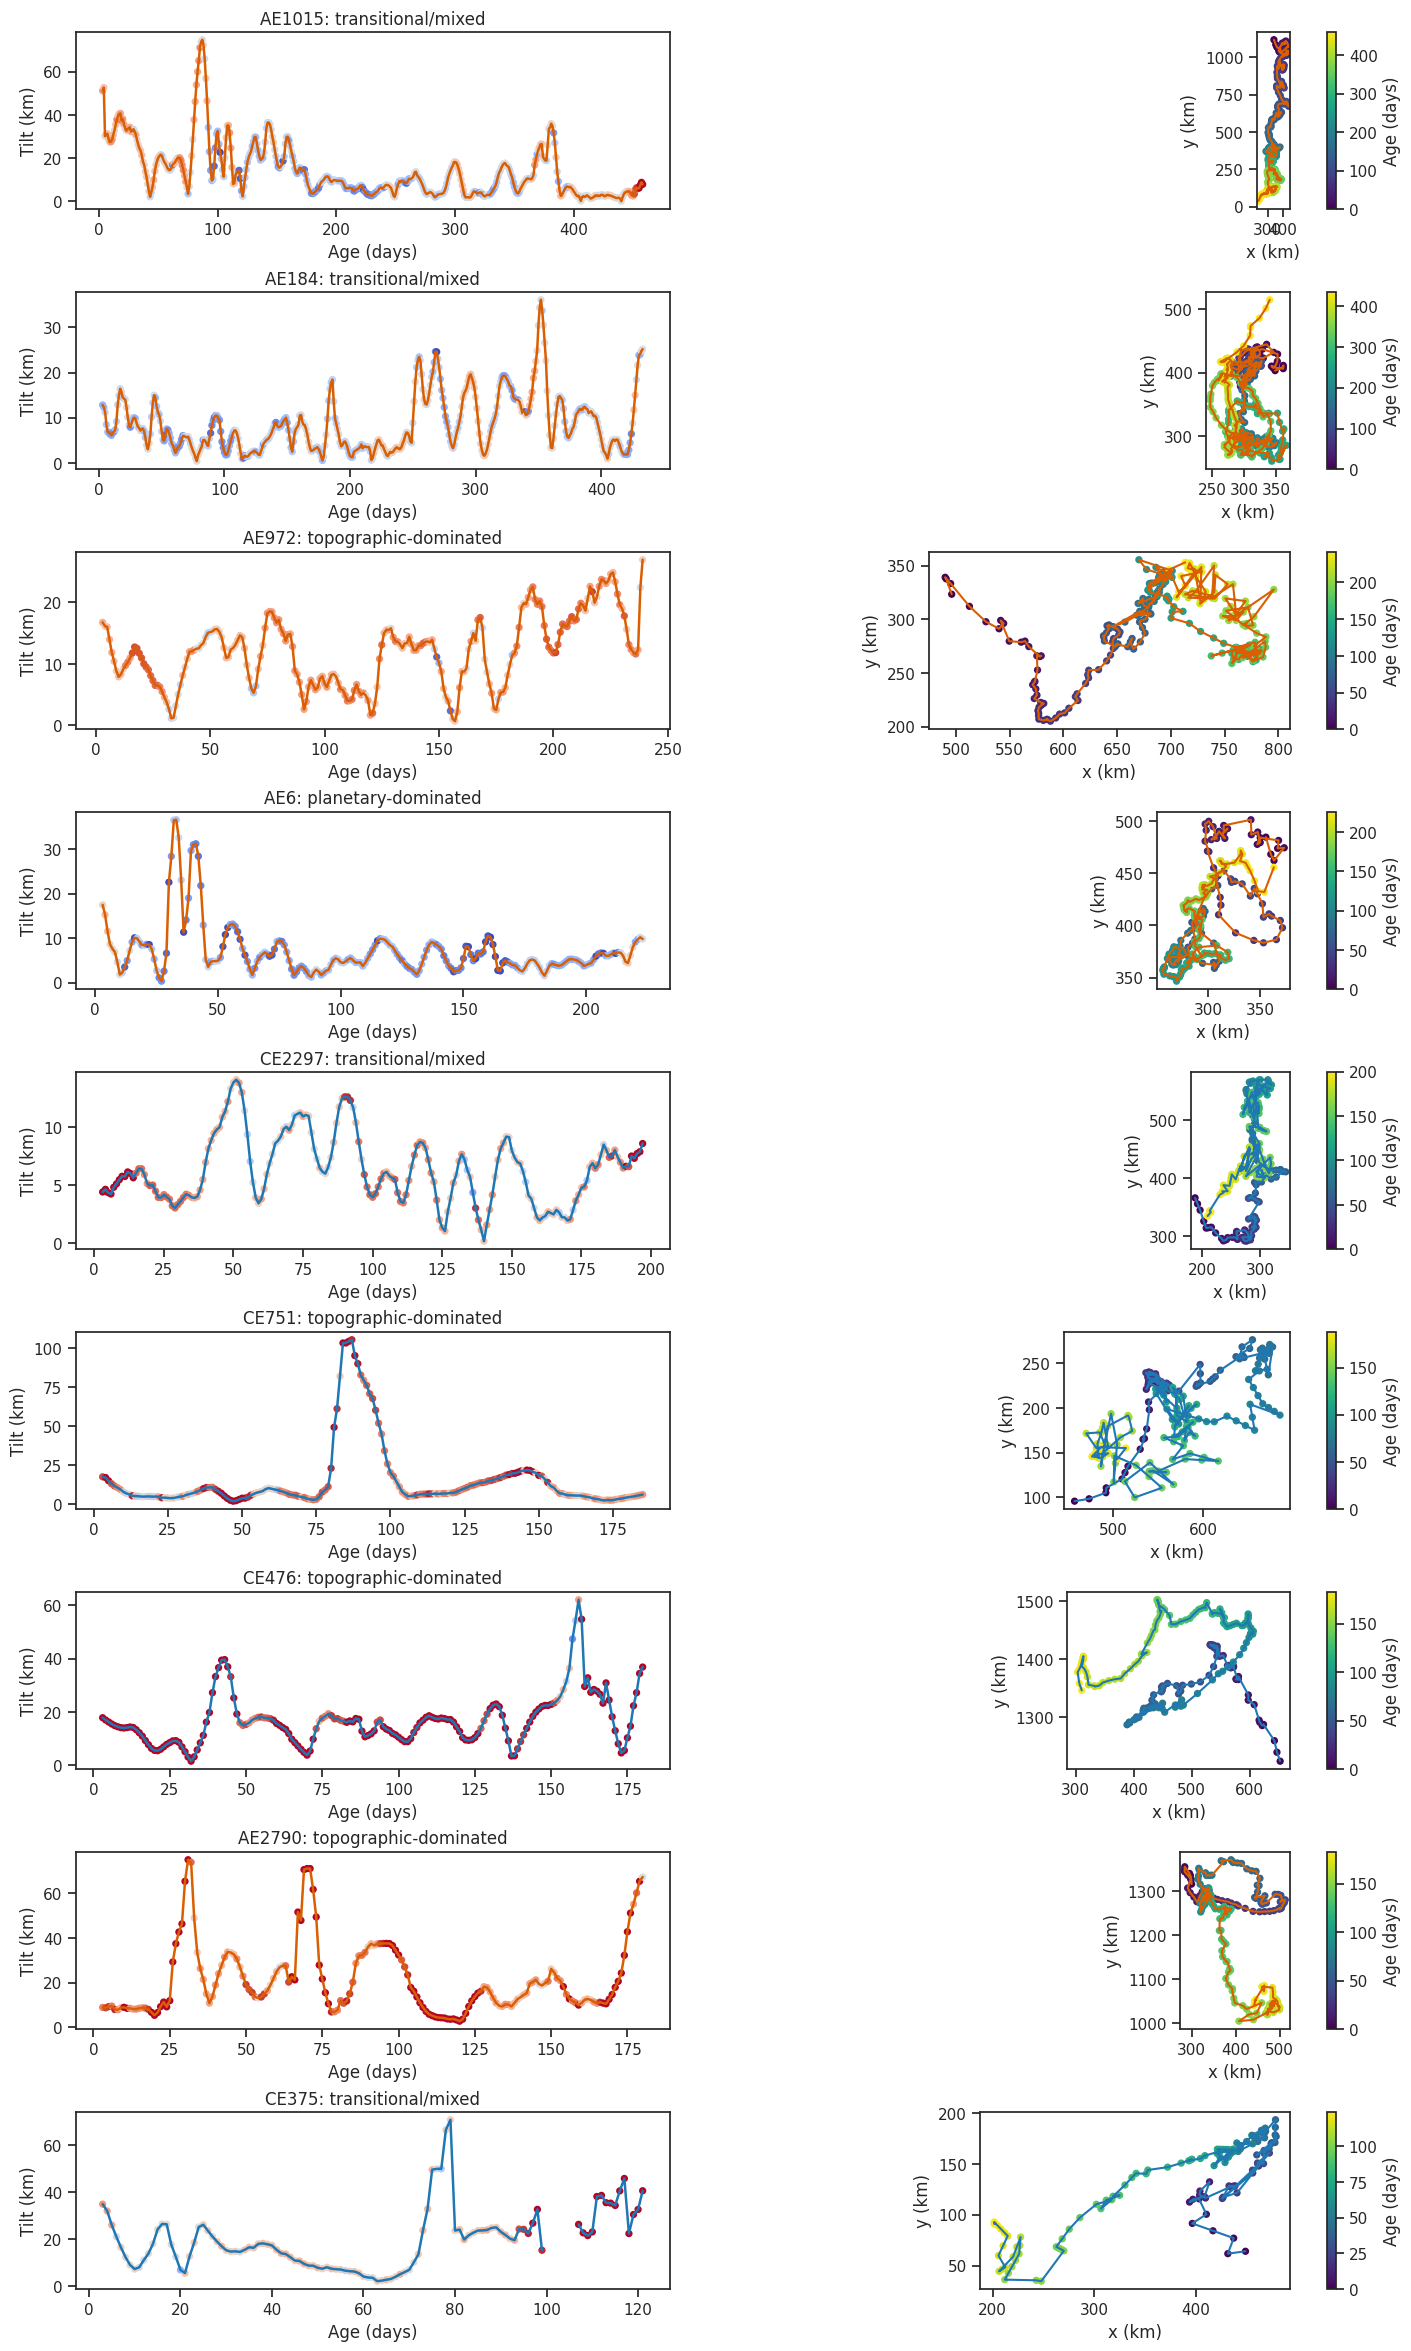

In [12]:
eligible = eddy_qc[(eddy_qc.lifetime_days >= 60) & (eddy_qc.coverage >= .6)].copy()
if eligible.empty:
    eligible = eddy_qc.sort_values("lifetime_days", ascending=False).groupby("Cyc").head(3)
selected = (eligible.sort_values("lifetime_days", ascending=False)
            .groupby(["Cyc", "PVExposure"], observed=True).head(2).Eddy.tolist())
fig, axes = plt.subplots(len(selected), 2, figsize=(14, max(4, 2.6 * len(selected))),
                         constrained_layout=True, squeeze=False)
for row, eddy in enumerate(selected):
    part = data[data.Eddy == eddy].sort_values("age_days")
    cyc, exposure = part.iloc[0][["Cyc", "PVExposure"]]
    axes[row, 0].plot(part.age_days, part.TiltDis, color=palette[cyc], lw=1.8)
    axes[row, 0].scatter(part.age_days, part.TiltDis, c=part.topo_plan_ratio_raw,
                         cmap="coolwarm", norm=LogNorm(vmin=.1, vmax=10), s=18)
    axes[row, 0].set(title=f"{cyc}{eddy}: {exposure}", xlabel="Age (days)", ylabel="Tilt (km)")
    axes[row, 1].plot(part.xc, part.yc, color=palette[cyc], lw=1.5)
    points = axes[row, 1].scatter(part.xc, part.yc, c=part.age_days, cmap="viridis", s=18)
    axes[row, 1].set(xlabel="x (km)", ylabel="y (km)", aspect="equal")
    fig.colorbar(points, ax=axes[row, 1], label="Age (days)")
plt.show()


In [13]:
# fig, axs = tilt.tilt_t(data.copy(), grid=grid, add_field='w', field_label='vort.')

,Cyc,transitions,switch_fraction
0,AE,63506,0.175275
1,CE,60938,0.124044


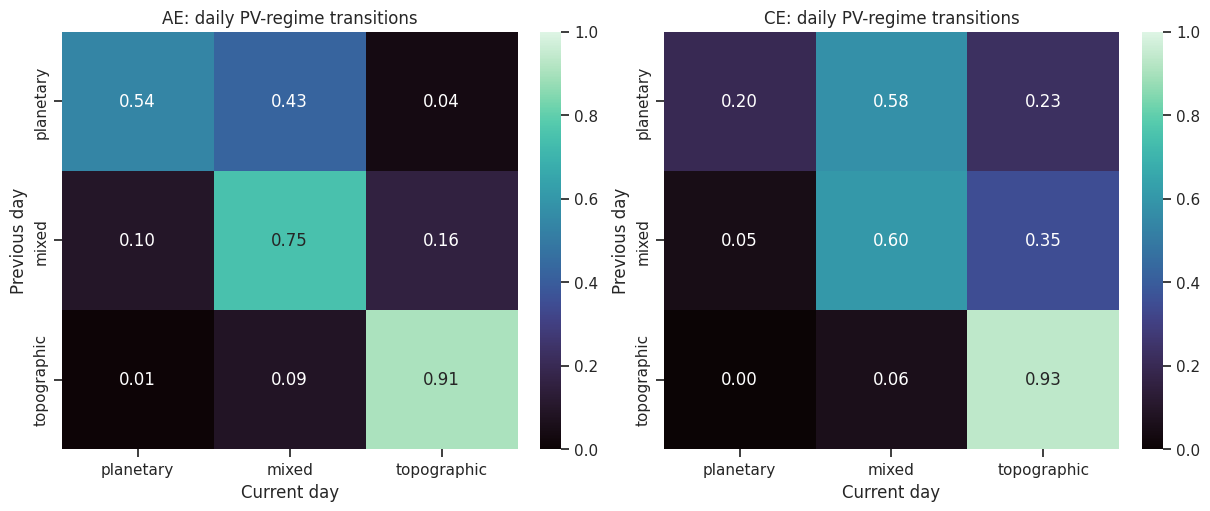

In [14]:
transition_data = data.sort_values(["Eddy", "Day"])[["Eddy", "Cyc", "PVRegime"]].copy()
transition_data["previous"] = transition_data.groupby("Eddy").PVRegime.shift()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
transition_rows = []
daily_order = ["planetary", "mixed", "topographic"]
for ax, cyc in zip(axes, ["AE", "CE"]):
    part = transition_data[transition_data.Cyc == cyc].dropna(subset=["previous"])
    matrix = pd.crosstab(part.previous, part.PVRegime, normalize="index").reindex(
        index=daily_order, columns=daily_order, fill_value=0)
    sns.heatmap(matrix, vmin=0, vmax=1, cmap="mako", annot=True, fmt=".2f", ax=ax)
    ax.set(title=f"{cyc}: daily PV-regime transitions", xlabel="Current day", ylabel="Previous day")
    switches = part.previous != part.PVRegime
    transition_rows.append({"Cyc": cyc, "transitions": len(part),
                            "switch_fraction": switches.mean()})
display(pd.DataFrame(transition_rows))
plt.show()


## Interpretation guide

Evidence for cumulative differential propagation would require several results to agree:

- positive within-eddy slopes and positive clustered age effects, not merely larger tilt in long-lived eddies;
- a positive-increment fraction above 0.5, particularly early in life, with possible later saturation shown by negative curvature;
- observed east/north tilt-vector changes that scale with surface-minus-deep displacement, ideally with slopes approaching one;
- directional offsets concentrated near zero; and
- coherent differences between sustained planetary and topographic exposure.

If ensemble tilt increases but daily kinematic component tests fail, age is likely acting as a proxy for another evolving property. If kinematic agreement occurs only in one PV-exposure class, the result supports a conditional rather than universal tilt-growth mechanism. Treat normalised-age patterns cautiously because an eddy's final lifetime is only known retrospectively.
